### Import Libraries

In [77]:
# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
import itertools

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# Statistics.
import scipy.stats as stats

# Data frames.
import pandas as pd

# Statistical plots.
import seaborn as sns

from scipy.stats import norm

### Task 1: Permutations and Combinations

In [78]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with milk in first.
no_cups_milk_first = 6

# Number of cups of tea with tea in first.
no_cups_tea_first = 6

In [79]:
# Number of ways of selecting four cups from eight.
ways = math.comb(no_cups, no_cups_milk_first)

# Show.
ways

924

### Task 2: numpy's Normal Distribution

In [80]:
sample = np.random.normal(10, 3, 100000)

In [81]:
stats.shapiro(sample)

c:\Users\Fujitsu\anaconda3\lib\site-packages\scipy\stats\_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9999698400497437, pvalue=0.5906857252120972)

(array([4.8000e+01, 6.3700e+02, 4.7240e+03, 1.7758e+04, 3.2243e+04,
        2.8720e+04, 1.2775e+04, 2.7720e+03, 3.0800e+02, 1.5000e+01]),
 array([-2.61218889e+00, -5.20022335e-03,  2.60178844e+00,  5.20877710e+00,
         7.81576577e+00,  1.04227544e+01,  1.30297431e+01,  1.56367318e+01,
         1.82437204e+01,  2.08507091e+01,  2.34576977e+01]),
 <BarContainer object of 10 artists>)

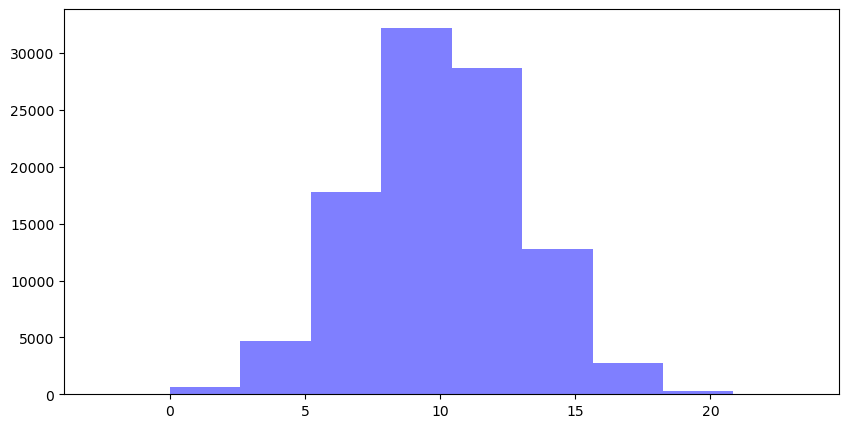

In [82]:
# Create an empty data frame.
fig, ax = plt.subplots(figsize=(10, 5))

# Create histogram.
ax.hist(sample, color='blue', alpha=0.5, label='Sample')

(array([2.87688248e-05, 2.10971382e-04, 5.27428454e-04, 1.53433732e-03,
        4.26737567e-03, 9.54166021e-03, 1.98217203e-02, 3.74474202e-02,
        5.97240802e-02, 8.90586919e-02, 1.14145107e-01, 1.28845976e-01,
        1.30341955e-01, 1.17453522e-01, 9.38247272e-02, 6.66285981e-02,
        4.23381204e-02, 2.37918181e-02, 1.15554779e-02, 4.77562491e-03,
        1.96586969e-03, 8.15116702e-04, 2.20560990e-04, 8.63064743e-05,
        9.58960825e-06]),
 array([-2.61218889, -1.56939342, -0.52659796,  0.51619751,  1.55899297,
         2.60178844,  3.6445839 ,  4.68737937,  5.73017484,  6.7729703 ,
         7.81576577,  8.85856123,  9.9013567 , 10.94415216, 11.98694763,
        13.02974309, 14.07253856, 15.11533402, 16.15812949, 17.20092495,
        18.24372042, 19.28651588, 20.32931135, 21.37210681, 22.41490228,
        23.45769774]),
 <BarContainer object of 25 artists>)

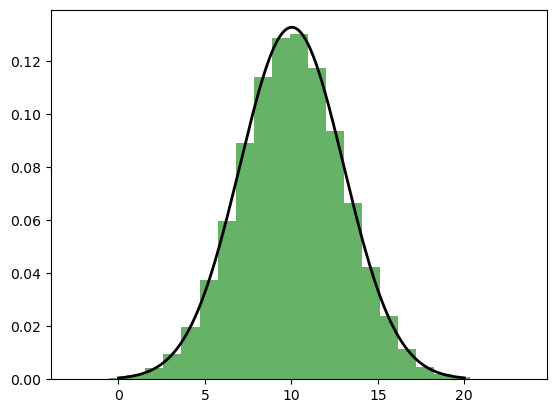

In [83]:
mu, std = norm.fit(sample)
x = np.linspace(0, 20, 1001)
p = norm.pdf(x, mu, std)
fig, ax = plt.subplots(1, 1) 
plt.plot(x, p, 'k', linewidth=2)
#ax.hist(sample, color='blue', alpha=0.5, label='Sample')
plt.hist(sample, bins=25, density=True, alpha=0.6, color='g')

### Task 3: t-Test Calculation

In [84]:
Before = [63,68,70,64,74,67,70,57,66,65]

In [85]:
After = [64,64,68,64,73,70,72,54,61,63]

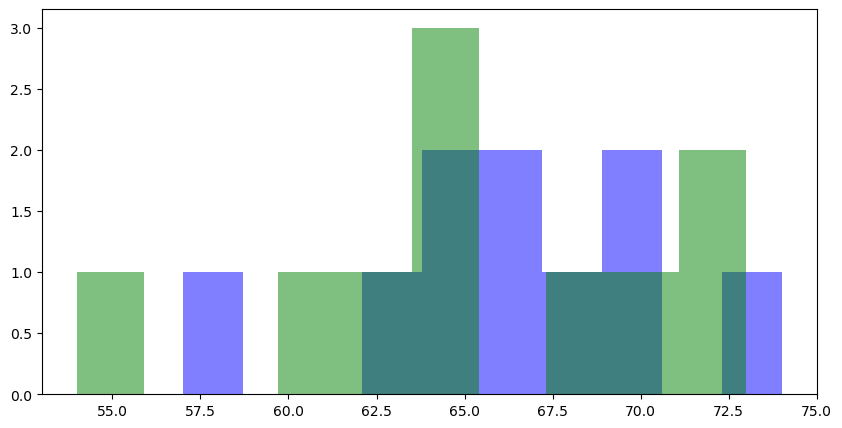

In [86]:
# Create an empty data frame.
fig, ax = plt.subplots(figsize=(10, 5))

# Create histogram.
ax.hist(Before, color='blue', alpha=0.5, label='Before')

# Create histogram.
ax.hist(After, color='green', alpha=0.5, label='After');

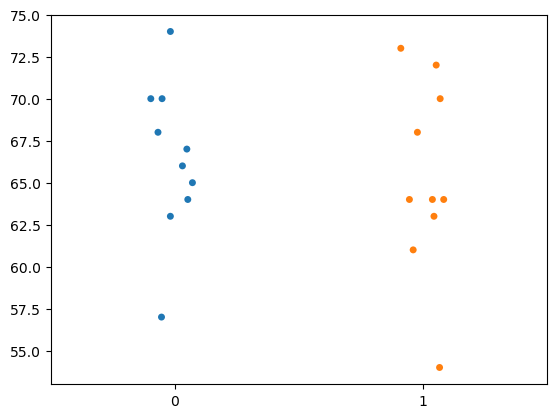

In [87]:
# Create a strip plot.
sns.stripplot(data=[Before, After]);

In [88]:
stats.ttest_ind(Before, After)

Ttest_indResult(statistic=0.4740968275126808, pvalue=0.6411310132871086)

pvalue=0.6411310132871086)

My p-value is greater than 0.05 which means there is no statistically significant differences between group means.

In [89]:
n = len(Before)
n
zipped_lists = zip(Before, After)
zipped_lists
numerator = [x - y for (x, y) in zipped_lists]
numerator
sum (numerator)
dem = [((y - x)**2) for (x, y) in zipped_lists]
dem
sum(dem)
dem = [((Before[i]-After[i])**2) for i in range(len(After))]
sum(dem)

73

In [90]:
def t_statistic(Before, After):
    n = len(Before)
    #numerator = sum(Before - After)
    #numerator = list(np.array(Before) - np.array(After))
    zipped_lists = zip(Before, After) 
    numerator = [x - y for (x, y) in zipped_lists]
    numerator = sum(numerator)
    dem = [((Before[i]-After[i])**2) for i in range(len(After))]
    s = sum(dem)/(n - 1)
    return numerator/(s/np.sqrt(n))

In [91]:
t_statistic(Before, After)

4.288568333653008

In [92]:
stats.ttest_rel(Before, After)

Ttest_relResult(statistic=1.337227482480628, pvalue=0.21396011317404623)

pvalue=0.21396011317404623)

My p-value is greater than 0.05 which means there is no statistically significant differences between group means.

### Task 4: ANOVA

In [93]:
no_type_ii = 0

In [94]:
# First sample.
sample_a = np.random.normal(loc=4.9, scale=0.1, size=100)

# Second sample.
sample_b = np.random.normal(loc=5.0, scale=0.1, size=100)

# Third sample.
sample_c = np.random.normal(loc=5.1, scale=0.1, size=100)

In [95]:
# Create data frame.
df = pd.DataFrame({'Sample_a': sample_a, 'Sample_b': sample_b, 'Sample_c': sample_c})

# Show.
df

,Sample_a,Sample_b,Sample_c
0,4.905309,5.052537,5.152946
1,4.966641,4.905940,5.081680
2,4.873574,4.983164,5.022249
3,4.780520,4.820699,5.124188
4,4.893515,4.971916,4.961368
...,...,...,...
95,4.827033,4.940967,5.080111
96,4.921484,4.864065,5.072147
97,4.880432,5.005785,5.017157
98,4.998943,4.958589,4.981554


In [96]:
df.describe()

,Sample_a,Sample_b,Sample_c
count,100.000000,100.000000,100.000000
mean,4.909876,4.976390,5.084348
std,0.083977,0.096234,0.100017
min,4.721700,4.706803,4.840641
25%,4.858634,4.900933,5.023153
50%,4.904459,4.989646,5.086269
75%,4.957749,5.041735,5.153396
max,5.229446,5.170573,5.311313


In [97]:
# Perform ANOVA.
f_statistic, p_value = stats.f_oneway(df['Sample_a'], df['Sample_b'], df['Sample_c'])

# Show.
f_statistic, p_value

(88.38483506394705, 7.6312455013226845e-31)

https://statistics.laerd.com/statistical-guides/one-way-anova-statistical-guide-4.php

pvalue=7.6312455013226845e-31)

My p-value is greater than 0.05 which means there were no statistically significant differences between group means.



In [98]:
# Tukey's HSD.
res = stats.tukey_hsd(df['Sample_a'], df['Sample_b'], df['Sample_c'])

# Show.
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.067     0.000    -0.098    -0.035
 (0 - 2)     -0.174     0.000    -0.206    -0.143
 (1 - 0)      0.067     0.000     0.035     0.098
 (1 - 2)     -0.108     0.000    -0.139    -0.077
 (2 - 0)      0.174     0.000     0.143     0.206
 (2 - 1)      0.108     0.000     0.077     0.139



In [99]:
#https://researchdatapod.com/type-ii-error-calculator/
import math
from scipy.stats import norm

def calculate_type_ii_error(n, alpha, d, sigma, test_type="two-tailed"):
    """
    Calculate Type II Error (β) for a given sample size, significance level, effect size, and standard deviation.

    Parameters:
        n (int): Sample size
        alpha (float): Significance level
        d (float): Effect size
        sigma (float): Standard deviation
        test_type (str): "one-tailed" or "two-tailed" test

    Returns:
        float: Type II Error (β)
    """
    if test_type == "two-tailed":
        alpha /= 2

    # Calculate Z-scores
    z_alpha = norm.ppf(1 - alpha)  # Critical Z for alpha
    z_power = (math.sqrt(n) * d / sigma) - z_alpha

    # Calculate Type II Error (β)
    beta = norm.cdf(z_power)
    if beta > 0.2:
        return True 
    else: 
        return False

# Example usage
n = 50
alpha = 0.05
d = 0.5
sigma = 1.0
test_type = "two-tailed"

beta = calculate_type_ii_error(n, alpha, d, sigma, test_type)
print(f"Type II Error (β): {beta:.5f}")
interpretation = "High β indicates low statistical power." 


Type II Error (β): 1.00000


In [100]:
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if calculate_type_ii_error(n, alpha, d, sigma) == True:
        # Increment the number of rejections.
        no_type_ii += 1

# Show the number of rejections.
no_type_ii

10000

In [101]:
for _ in range(10000):
    sample_a = np.random.normal(loc=4.9, scale=0.1, size=100)
    sample_b = np.random.normal(loc=5.0, scale=0.1, size=100)
    sample_c = np.random.normal(loc=5.1, scale=0.1, size=100)
    df = pd.DataFrame({'Sample_a': sample_a, 'Sample_b': sample_b, 'Sample_c': sample_c})
    f_statistic, p_value = stats.f_oneway(df['Sample_a'], df['Sample_b'], df['Sample_c'])
    #if p_value<(1-0.05):
        #no_type_ii += 1
    # Check if the null hypothesis is rejected.
    if calculate_type_ii_error(n=100, alpha=p_value, d=f_statistic, sigma=0.1) == True:
        #Increment the number of rejections.
        no_type_ii += 1

# Show the number of rejections.
no_type_ii

10000